### well structured - an ode to databases


# data preparation

### import libraries

In [77]:
import sqlite3
import pandas as pd
import numpy as np

## handling missing values

### create table brexit_progress

In [78]:
# create table
conn = sqlite3.connect('brexit.db')
c = conn.cursor()

sql = "CREATE TABLE brexit_progress (id_brexit_progress INTEGER PRIMARY KEY AUTOINCREMENT, start DATE, end DATE, description VARCHAR(255), updated DATE)"
c.execute(sql)

brexit_progresses = [[2008, 2015, 'before referendum', 'date()'],[2016, 2020, 'before brexit', 'date()'],[2021, 2022, 'after brexit', 'date()']]
for brexit_progress in brexit_progresses:
    sql = "INSERT INTO brexit_progress (start, end, description, updated) VALUES (" + str(brexit_progress[0]) + "," + str(brexit_progress[1]) + ",'" + str(brexit_progress[2]) + "'," + str(brexit_progress[3]) + ")"
    c.execute(sql) 

conn.commit()
conn.close()

In [79]:
conn = sqlite3.connect('brexit.db')
c = conn.cursor()

sql = "ALTER TABLE `economic-growth` ADD COLUMN f_id_brexit_progress"
c.execute(sql)

sql = "ALTER TABLE `economic-growth` ADD COLUMN updated"
c.execute(sql)

sql = "ALTER TABLE migration ADD f_id_brexit_progress"
c.execute(sql)

sql = "ALTER TABLE migration ADD updated"
c.execute(sql)

sql = "UPDATE `economic-growth` SET f_id_brexit_progress = 0, updated = datetime() WHERE Jahr = 2007"
c.execute(sql) 

sql = "UPDATE `economic-growth` SET f_id_brexit_progress = 1, updated = datetime() WHERE Jahr > 2007"
c.execute(sql)

sql = "UPDATE `economic-growth` SET f_id_brexit_progress = 2, updated = datetime() WHERE Jahr > 2016"
c.execute(sql)

sql = "UPDATE `economic-growth` SET f_id_brexit_progress = 3, updated = datetime() WHERE Jahr > 2020"
c.execute(sql)

sql = "UPDATE migration SET f_id_brexit_progress = 0, updated = datetime() WHERE Year = 2007"
c.execute(sql)

sql = "UPDATE migration SET f_id_brexit_progress = 1, updated = datetime() WHERE Year > 2007"
c.execute(sql)

sql = "UPDATE migration SET f_id_brexit_progress = 2, updated = datetime() WHERE Year > 2016"
c.execute(sql)

sql = "UPDATE migration SET f_id_brexit_progress = 3 , updated = datetime() WHERE Year > 2020"
c.execute(sql)

sql = "ALTER TABLE `economic-growth` DROP COLUMN `EU-27`"
c.execute(sql)

sql = "ALTER TABLE `economic-growth` RENAME COLUMN Jahr TO year"
c.execute(sql)

sql = "ALTER TABLE `economic-growth` RENAME COLUMN Germany TO germany"
c.execute(sql)

sql = "ALTER TABLE `economic-growth` RENAME COLUMN `United Kingdom` TO united_kingdom"
c.execute(sql)

sql = "ALTER TABLE `economic-growth` RENAME TO economic_growth"
c.execute(sql)

sql = "ALTER TABLE migration RENAME COLUMN Year TO year"
c.execute(sql)

sql = "ALTER TABLE migration RENAME COLUMN Immigration TO immigration"
c.execute(sql)

sql = "ALTER TABLE migration RENAME COLUMN Emigration TO emigration"
c.execute(sql)

conn.commit()
conn.close()

## create tables

In [80]:
conn = sqlite3.connect('brexit.db')
c = conn.cursor()

sql = "CREATE TABLE lin_reg_migration (id_lin_reg_migration INTEGER PRIMARY KEY AUTOINCREMENT, f_id_brexit_progress INT(10), avg_year DATE, avg_immigration INT(255), avg_emigration INT(255), b INT(10), updated DATE)"
c.execute(sql)

sql = "CREATE TABLE lin_reg_economic_growth (id_lin_reg_economic_growth INTEGER PRIMARY KEY AUTOINCREMENT, f_id_brexit_progress INT(10), avg_year DATE, avg_germany INT(255), avg_united_kingdom INT(255), b INT(10), updated DATE)"
c.execute(sql)

conn.commit()
conn.close()

# --------------------------------------------------

## modify tables

In [65]:
conn = sqlite3.connect('brexit.db')

c = conn.cursor()
sql = "ALTER TABLE `economic-growth` DROP COLUMN `EU-27`"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE `economic-growth` RENAME COLUMN Jahr TO year"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE `economic-growth` RENAME COLUMN Germany TO germany"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE `economic-growth` RENAME COLUMN `United Kingdom` TO united_kingdom"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE `economic-growth` RENAME TO economic_growth"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE migration RENAME COLUMN Year TO year"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE migration RENAME COLUMN Immigration TO immigration"
c.execute(sql)

c = conn.cursor()
sql = "ALTER TABLE migration RENAME COLUMN Emigration TO emigration"
c.execute(sql)

conn.commit()
conn.close()

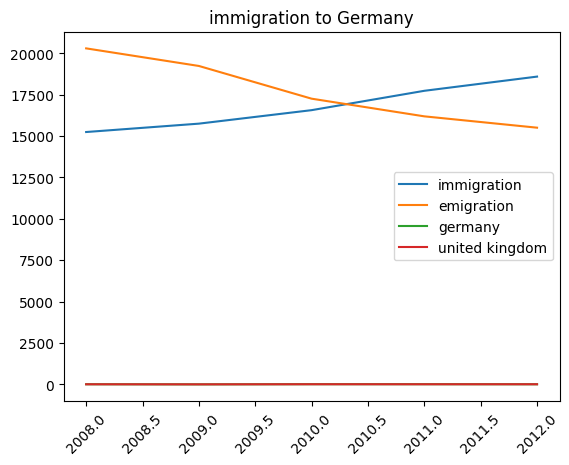

In [50]:
conn = sqlite3.connect('brexit.db')

sql = "SELECT * FROM 'migration' WHERE flag = 1 ORDER BY Year LIMIT 5"
result = pd.read_sql(sql,conn)
year = result['Year'].tolist()
immigration = result['Immigration'].tolist()
emigration = result['Emigration'].tolist()

sql = "SELECT Jahr, Germany, `United Kingdom` FROM `economic-growth` WHERE flag = 1 ORDER BY Jahr LIMIT 5"
result = pd.read_sql(sql,conn)
year = result['Jahr'].tolist()
germany = result['Germany'].tolist()
germany = [np.NaN if x=='NaN' else x for x in germany]
united_kingdom = result['United Kingdom'].tolist()
united_kingdom = [np.NaN if x=='NaN' else x for x in united_kingdom]

df = pd.DataFrame({'immigration': immigration, 'emigration': emigration, 'germany': germany, 'united kingdom': united_kingdom}, index=year)
plot = df.plot(title="immigration to Germany", rot=45)

conn.close()

### create table for linear regression economic_growth

In [54]:
c = conn.cursor()
sql = "INSERT INTO lin_reg_migration (id_lin_reg_migration, year, Immigration, Emigration, b, updated) VALUES (2011, 17406, 18043, 5869, date()"
c.execute(sql)

ProgrammingError: Cannot operate on a closed database.

In [ ]:
c = conn.cursor()
sql = "CREATE TABLE lin_reg_migration (id_lin_reg_economic_growth INT(10) primary key auto_increment, year DATE, germany INT(255), united_kingdom INT(255), b INT(10), updated date)"
c.execute(sql)

In [ ]:
c = conn.cursor()
sql = "INSERT INTO lin_reg_economic_growth (year, germany, united_kingdom, b, updated) VALUES (2011, 17406, 18043, 5869, date())"
c.execute(sql)